## WORLDQUANT → PYTHON RESEARCH PIPELINE (Event-Driven Volume + Reversal Alpha)

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


## Download Data (HANDLE MULTIINDEX PROPERLY)

In [34]:
def download_data(tickers, start, end):

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    # --------------------------------------------------
    # CASE 1: Multiple tickers (MultiIndex columns)
    # --------------------------------------------------
    if isinstance(raw.columns, pd.MultiIndex):

        df = (
            raw
            .stack(level=1, future_stack=True)  # stack TICKER level
            .rename_axis(["Date", "Ticker"])
            .reset_index()
        )

    # --------------------------------------------------
    # CASE 2: Single ticker
    # --------------------------------------------------
    else:
        raw["Ticker"] = tickers if isinstance(tickers, str) else tickers[0]
        df = raw.reset_index()

    # --------------------------------------------------
    # Clean & Sort
    # --------------------------------------------------
    df = df.sort_values(["Ticker", "Date"])
    df = df.dropna(subset=["Close", "Volume"])

    return df


In [35]:
df


Price,Date,Ticker,Close,High,Low,Open,Volume
0,2020-01-02,AAPL,72.400513,72.460776,71.156674,71.409778,135480400
1,2020-01-03,AAPL,71.696648,72.455966,71.472469,71.629153,146322800
2,2020-01-06,AAPL,72.267929,72.306499,70.568503,70.819201,118387200
3,2020-01-07,AAPL,71.928047,72.533087,71.708687,72.277571,108872000
4,2020-01-08,AAPL,73.085106,73.386423,71.631552,71.631552,132079200
...,...,...,...,...,...,...,...
5025,2023-12-22,XOM,95.059563,96.020324,94.975609,95.432669,12927800
5026,2023-12-26,XOM,95.274101,96.104274,95.255449,95.833768,16835100
5027,2023-12-27,XOM,94.826370,95.656543,94.527874,95.180824,14558800
5028,2023-12-28,XOM,93.455193,94.779738,93.399221,94.574525,16329300


## Feature Engineering (WorldQuant Operators → Python)
## | WorldQuant        | Python                         |
## | ----------------- | ------------------------------ |
## | `ts_delta(x,n)`   | `x - x.shift(n)`               |
## | `ts_sum(x,n)`     | `x.rolling(n).sum()`           |
## | `ts_arg_max(x,n)` | `rolling().apply(np.argmax)`   |
## | `rank(x)`         | `groupby(Date).rank(pct=True)` |


In [30]:
def build_signal(df):
    df = df.copy()
    
    # Trigger condition (volume spike)
    trigger = (
        (df["vol_rank"] > 0.9) &
        (df["Volume"] >= df["vol_mean_5"])
    )
    
    # Reversal signal
    alpha_raw = -df["delta_2"]
    
    # Apply trigger
    df["alpha_raw"] = np.where(trigger, alpha_raw, 0)
    
    # Cross-sectional z-score normalization
    df["alpha_final"] = (
        df.groupby("Date")["alpha_raw"]
          .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
    )
    
    # Apply trend filter
    df["alpha_final"] *= df["trend_filter"]
    
    # Clip extremes
    df["alpha_final"] = df["alpha_final"].clip(-3, 3)
    
    return df


## Trigger Logic (trade_when equivalent)
## trigger = ts_arg_max(volume,5) < 1 && volume >= avg(volume,5)
## alpha   = -rank(ts_delta(close,2))


In [31]:
def backtest(df, transaction_cost=0.0005):
    df = df.copy()
    
    # Strategy return
    df["strategy_return"] = df["alpha_final"] * df["forward_return"]
    
    # Turnover
    df["position_change"] = (
        df.groupby("Ticker")["alpha_final"]
          .diff()
          .abs()
    )
    
    df["cost"] = transaction_cost * df["position_change"]
    df["net_return"] = df["strategy_return"] - df["cost"]
    
    portfolio = df.groupby("Date")["net_return"].mean()
    
    equity_curve = (1 + portfolio).cumprod()
    
    return df, portfolio, equity_curve


## Peformance dashboard

In [32]:
def performance_dashboard(portfolio_returns, equity_curve, df):
    
    sharpe = np.sqrt(252) * portfolio_returns.mean() / portfolio_returns.std()
    
    rolling_max = equity_curve.cummax()
    drawdown = (equity_curve - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    turnover = df.groupby("Date")["position_change"].mean().mean()
    
    hit_rate = (portfolio_returns > 0).sum() / len(portfolio_returns)
    
    print("===== PERFORMANCE DASHBOARD =====")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print(f"Average Turnover: {turnover:.4f}")
    print(f"Hit Rate: {hit_rate:.2%}")
    
    # === Plots ===
    
    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    
    # Equity curve
    axes[0,0].plot(equity_curve)
    axes[0,0].set_title("Equity Curve")
    
    # Drawdown
    axes[0,1].plot(drawdown, color="red")
    axes[0,1].set_title("Drawdown")
    
    # Daily Returns Distribution
    sns.histplot(portfolio_returns, bins=50, ax=axes[1,0])
    axes[1,0].set_title("Return Distribution")
    
    # Turnover
    daily_turnover = df.groupby("Date")["position_change"].mean()
    axes[1,1].plot(daily_turnover)
    axes[1,1].set_title("Daily Turnover")
    
    plt.tight_layout()
    plt.show()


## VISUALIZATIONS

===== PERFORMANCE DASHBOARD =====
Sharpe Ratio: 0.41
Max Drawdown: -12.94%
Average Turnover: 0.2332
Hit Rate: 17.56%


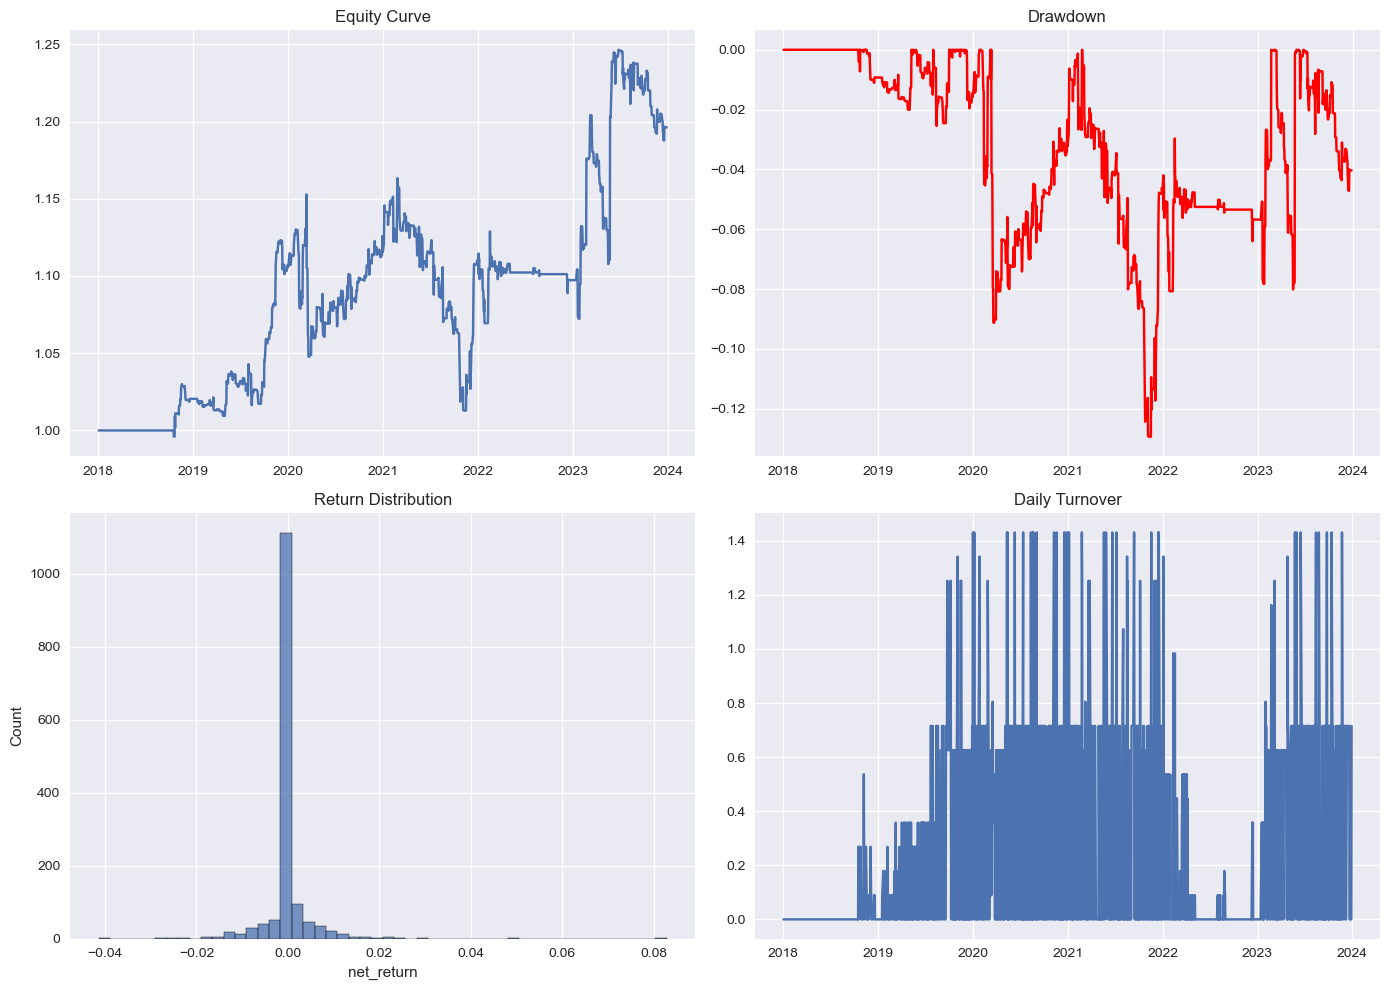

In [36]:
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META"]
start = "2018-01-01"
end = "2024-01-01"

df = download_data(tickers, start, end)
df = build_features(df)
df = build_signal(df)
df, portfolio_returns, equity_curve = backtest(df)

performance_dashboard(portfolio_returns, equity_curve, df)
